In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'numpy==1.23.5', 'pandas', '--upgrade', '-q'])

0

In [2]:
#!pip install pyarrow s3fs --quiet

import boto3
import pandas as pd
import pyarrow.parquet as pq
import s3fs

# Verificar conexión a S3
s3 = boto3.client("s3")
response = s3.list_objects_v2(Bucket="embalses-colombia", Prefix="data/raw/embalse_guatape/volumen_util_m3/")
for obj in response.get("Contents", []):
    print(obj["Key"])

data/raw/embalse_guatape/volumen_util_m3/year=2015/month=01/data.parquet
data/raw/embalse_guatape/volumen_util_m3/year=2015/month=02/data.parquet
data/raw/embalse_guatape/volumen_util_m3/year=2015/month=03/data.parquet
data/raw/embalse_guatape/volumen_util_m3/year=2015/month=04/data.parquet
data/raw/embalse_guatape/volumen_util_m3/year=2015/month=05/data.parquet
data/raw/embalse_guatape/volumen_util_m3/year=2015/month=06/data.parquet
data/raw/embalse_guatape/volumen_util_m3/year=2015/month=07/data.parquet
data/raw/embalse_guatape/volumen_util_m3/year=2015/month=08/data.parquet
data/raw/embalse_guatape/volumen_util_m3/year=2015/month=09/data.parquet
data/raw/embalse_guatape/volumen_util_m3/year=2015/month=10/data.parquet
data/raw/embalse_guatape/volumen_util_m3/year=2015/month=11/data.parquet
data/raw/embalse_guatape/volumen_util_m3/year=2015/month=12/data.parquet
data/raw/embalse_guatape/volumen_util_m3/year=2016/month=01/data.parquet
data/raw/embalse_guatape/volumen_util_m3/year=2016/

In [3]:
#!pip install pyarrow s3fs --quiet

import boto3
import pandas as pd
import pyarrow.parquet as pq
import s3fs

# Verificar conexión a S3
s3 = boto3.client("s3")
response = s3.list_objects_v2(Bucket="embalses-colombia", Prefix="data/raw/embalse_guatape/volumen_util_m3/")
for obj in response.get("Contents", []):
    print(obj["Key"])

data/raw/embalse_guatape/volumen_util_m3/year=2015/month=01/data.parquet
data/raw/embalse_guatape/volumen_util_m3/year=2015/month=02/data.parquet
data/raw/embalse_guatape/volumen_util_m3/year=2015/month=03/data.parquet
data/raw/embalse_guatape/volumen_util_m3/year=2015/month=04/data.parquet
data/raw/embalse_guatape/volumen_util_m3/year=2015/month=05/data.parquet
data/raw/embalse_guatape/volumen_util_m3/year=2015/month=06/data.parquet
data/raw/embalse_guatape/volumen_util_m3/year=2015/month=07/data.parquet
data/raw/embalse_guatape/volumen_util_m3/year=2015/month=08/data.parquet
data/raw/embalse_guatape/volumen_util_m3/year=2015/month=09/data.parquet
data/raw/embalse_guatape/volumen_util_m3/year=2015/month=10/data.parquet
data/raw/embalse_guatape/volumen_util_m3/year=2015/month=11/data.parquet
data/raw/embalse_guatape/volumen_util_m3/year=2015/month=12/data.parquet
data/raw/embalse_guatape/volumen_util_m3/year=2016/month=01/data.parquet
data/raw/embalse_guatape/volumen_util_m3/year=2016/

In [4]:
import s3fs

fs = s3fs.S3FileSystem()

# Leer todos los parquet de una vez
dataset = pq.ParquetDataset(
    "embalses-colombia/data/raw/embalse_guatape/volumen_util_m3/",
    filesystem=fs
)
df = dataset.read().to_pandas()

print(f"Shape: {df.shape}")
print(f"\nColumnas: {df.columns.tolist()}")
print(f"\nPrimeras filas:")
df.head()

Shape: (4168, 6)

Columnas: ['Id', 'Name', 'Value', 'Date', 'year', 'month']

Primeras filas:


,Id,Name,Value,Date,year,month
0,Embalse,PENOL,869500000.0,2015-01-01,2015,1
1,Embalse,PENOL,865969000.0,2015-01-02,2015,1
2,Embalse,PENOL,861594000.0,2015-01-03,2015,1
3,Embalse,PENOL,858406000.0,2015-01-04,2015,1
4,Embalse,PENOL,854719000.0,2015-01-05,2015,1


In [5]:
#%pip install matplotlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ─── 1. Análisis básico ───────────────────────────────────────────────────────
print("=" * 50)
print("1. INFORMACIÓN GENERAL")
print("=" * 50)
print(df.info())

print("\n" + "=" * 50)
print("2. ESTADÍSTICAS DESCRIPTIVAS")
print("=" * 50)
print(df["Value"].describe())

print("\n" + "=" * 50)
print("3. VALORES NULOS")
print("=" * 50)
print(df.isnull().sum())

print("\n" + "=" * 50)
print("4. RANGO TEMPORAL")
print("=" * 50)
df["Date"] = pd.to_datetime(df["Date"])
print(f"Fecha inicio : {df['Date'].min().date()}")
print(f"Fecha fin    : {df['Date'].max().date()}")
print(f"Total días   : {(df['Date'].max() - df['Date'].min()).days}")
print(f"Registros    : {len(df)}")
dias_esperados = (df['Date'].max() - df['Date'].min()).days + 1
print(f"Días faltantes: {dias_esperados - len(df)}")

1. INFORMACIÓN GENERAL
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4168 entries, 0 to 4167
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Id      4168 non-null   object        
 1   Name    4168 non-null   object        
 2   Value   4168 non-null   float64       
 3   Date    4168 non-null   datetime64[ns]
 4   year    4168 non-null   category      
 5   month   4168 non-null   category      
dtypes: category(2), datetime64[ns](1), float64(1), object(2)
memory usage: 139.1+ KB
None

2. ESTADÍSTICAS DESCRIPTIVAS
count    4.168000e+03
mean     8.021256e+08
std      1.889336e+08
min      3.342760e+08
25%      6.560580e+08
50%      8.374675e+08
75%      9.493100e+08
max      1.087144e+09
Name: Value, dtype: float64

3. VALORES NULOS
Id       0
Name     0
Value    0
Date     0
year     0
month    0
dtype: int64

4. RANGO TEMPORAL
Fecha inicio : 2015-01-01
Fecha fin    : 2026-05-31
Total días   : 4168
Regist

Día(s) faltante(s): [Timestamp('2015-12-31 00:00:00')]


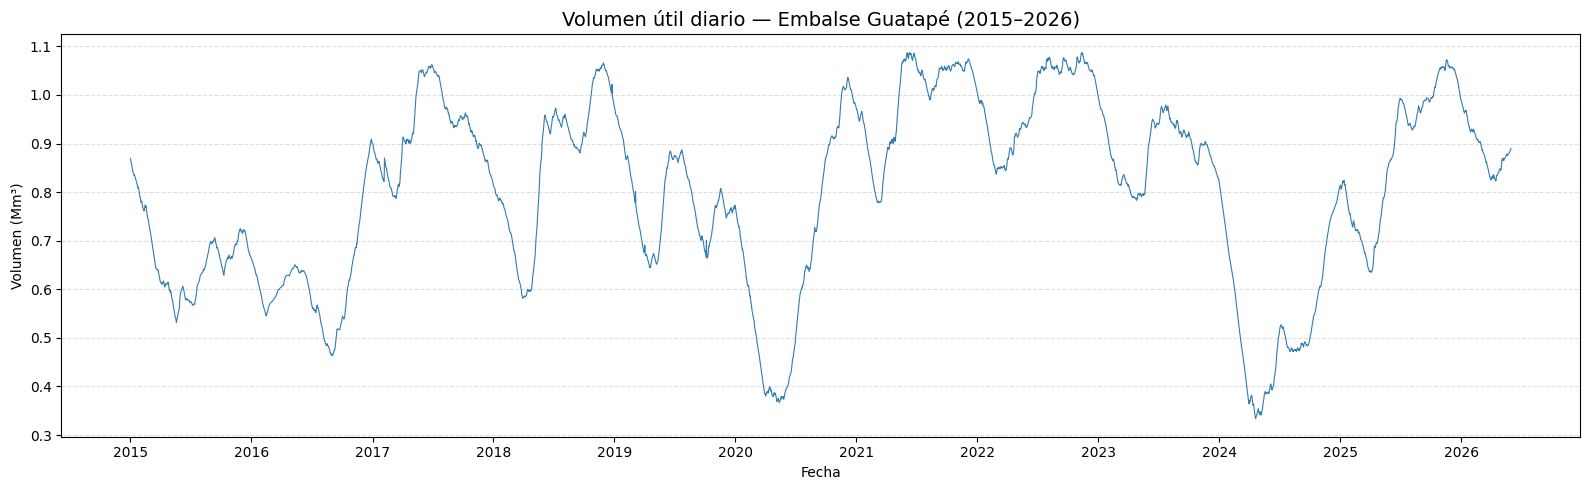

In [6]:
# ─── 5. IDENTIFICAR DÍA FALTANTE ─────────────────────────────────────────────
rango_completo = pd.date_range(start=df["Date"].min(), end=df["Date"].max(), freq="D")
dias_faltantes = rango_completo.difference(df["Date"])
print(f"Día(s) faltante(s): {dias_faltantes.tolist()}")

# ─── 6. SERIE DE TIEMPO COMPLETA ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df["Date"], df["Value"] / 1e9, color="#1a6fa8", linewidth=0.8, alpha=0.9)
ax.set_title("Volumen útil diario — Embalse Guatapé (2015–2026)", fontsize=14)
ax.set_ylabel("Volumen (Mm³)")
ax.set_xlabel("Fecha")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

/tmp/ipykernel_7933/231420779.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data_por_mes, labels=meses, patch_artist=True,


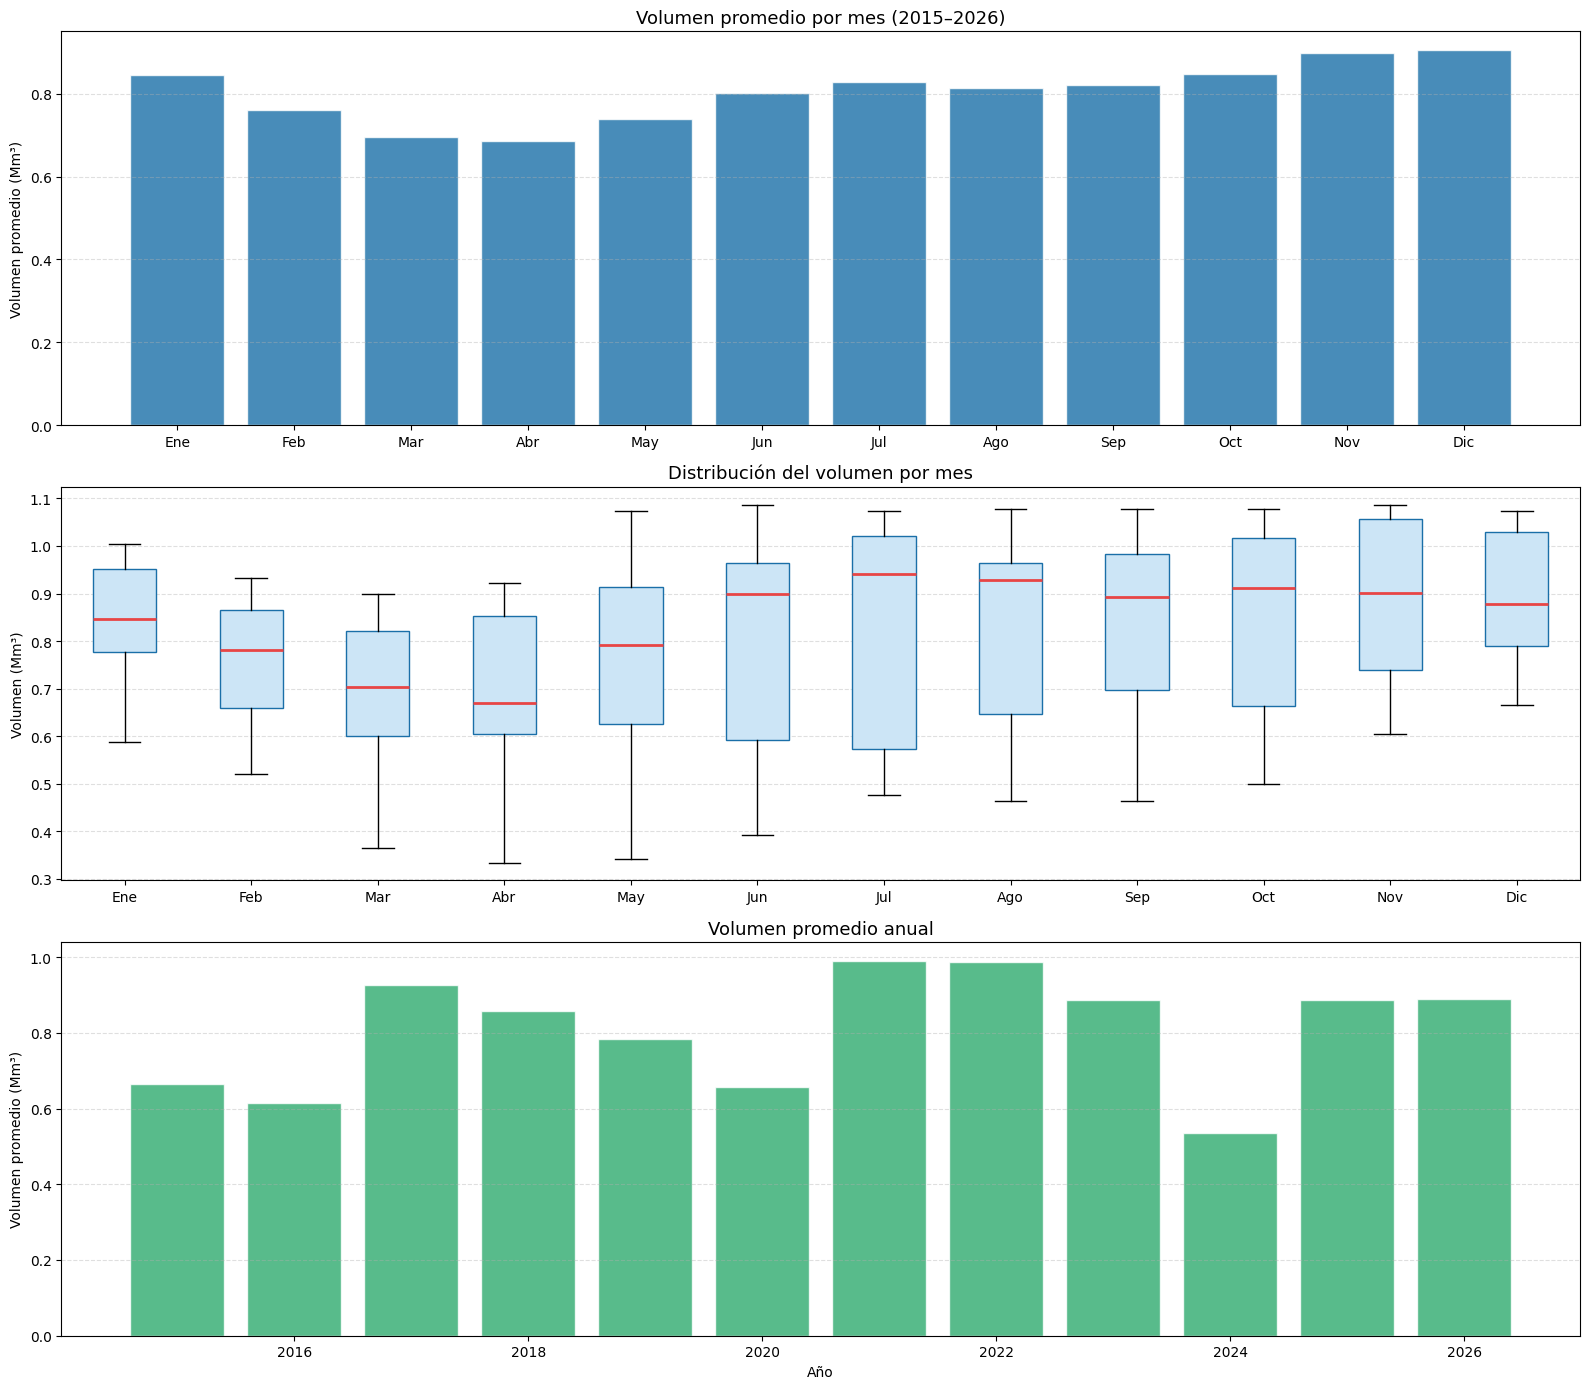

In [7]:
# ─── 7. ANÁLISIS ESTACIONAL ───────────────────────────────────────────────────
df["day_of_year"] = df["Date"].dt.dayofyear
df["month_num"]   = df["Date"].dt.month
df["year_num"]    = df["Date"].dt.year

fig, axes = plt.subplots(3, 1, figsize=(16, 14))

# --- 7.1 Volumen promedio por mes ---
monthly_avg = df.groupby("month_num")["Value"].mean() / 1e9
meses = ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"]
axes[0].bar(range(1, 13), monthly_avg, color="#1a6fa8", alpha=0.8, edgecolor="white")
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(meses)
axes[0].set_title("Volumen promedio por mes (2015–2026)", fontsize=13)
axes[0].set_ylabel("Volumen promedio (Mm³)")
axes[0].grid(axis="y", linestyle="--", alpha=0.4)

# --- 7.2 Boxplot por mes ---
data_por_mes = [df[df["month_num"] == m]["Value"].values / 1e9 for m in range(1, 13)]
axes[1].boxplot(data_por_mes, labels=meses, patch_artist=True,
                boxprops=dict(facecolor="#cce5f6", color="#1a6fa8"),
                medianprops=dict(color="#e84545", linewidth=2))
axes[1].set_title("Distribución del volumen por mes", fontsize=13)
axes[1].set_ylabel("Volumen (Mm³)")
axes[1].grid(axis="y", linestyle="--", alpha=0.4)

# --- 7.3 Volumen por año ---
yearly_avg = df.groupby("year_num")["Value"].mean() / 1e9
axes[2].bar(yearly_avg.index, yearly_avg.values, color="#2eaa6e", alpha=0.8, edgecolor="white")
axes[2].set_title("Volumen promedio anual", fontsize=13)
axes[2].set_ylabel("Volumen promedio (Mm³)")
axes[2].set_xlabel("Año")
axes[2].grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

Note: you may need to restart the kernel to use updated packages.
PRUEBA DICKEY-FULLER AUMENTADA
Estadístico ADF : -3.4951
p-valor         : 0.0081
Lags usados     : 14
Observaciones   : 4153

Valores críticos:
  1%: -3.4319
  5%: -2.8622
  10%: -2.5671

→ La serie ES estacionaria (p < 0.05)


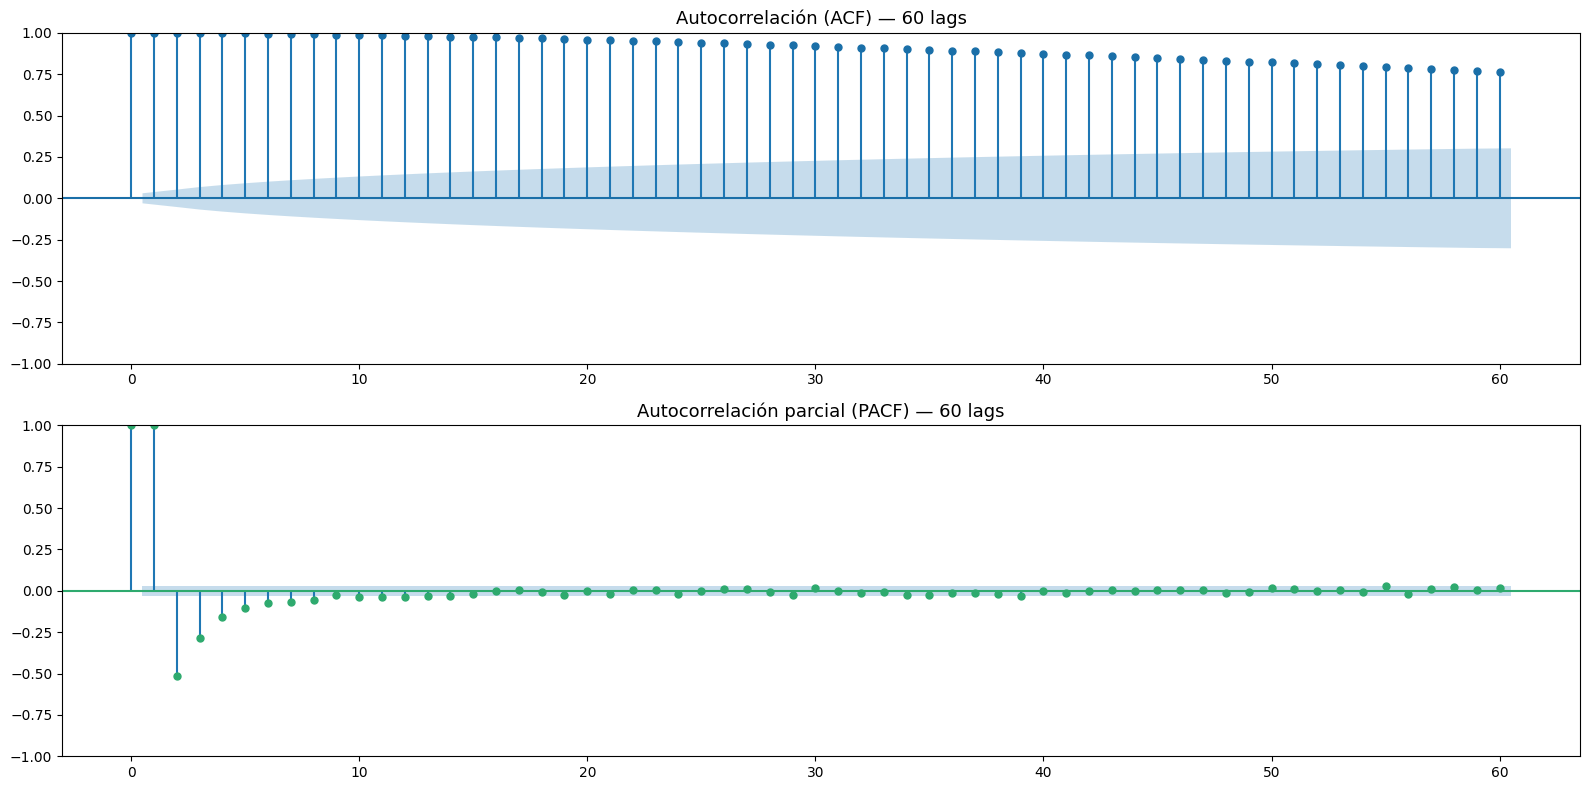

In [10]:
#%pip install statsmodels --quiet

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

# ─── 8. PRUEBA DE ESTACIONARIEDAD (ADF) ──────────────────────────────────────
serie = df.sort_values("Date").set_index("Date")["Value"]

resultado_adf = adfuller(serie, autolag="AIC")
print("=" * 50)
print("PRUEBA DICKEY-FULLER AUMENTADA")
print("=" * 50)
print(f"Estadístico ADF : {resultado_adf[0]:.4f}")
print(f"p-valor         : {resultado_adf[1]:.4f}")
print(f"Lags usados     : {resultado_adf[2]}")
print(f"Observaciones   : {resultado_adf[3]}")
print("\nValores críticos:")
for key, val in resultado_adf[4].items():
    print(f"  {key}: {val:.4f}")

if resultado_adf[1] < 0.05:
    print("\n→ La serie ES estacionaria (p < 0.05)")
else:
    print("\n→ La serie NO ES estacionaria (p >= 0.05) — requiere diferenciación")

# ─── 9. ACF Y PACF ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 8))
plot_acf(serie, lags=60, ax=axes[0], color="#1a6fa8")
axes[0].set_title("Autocorrelación (ACF) — 60 lags", fontsize=13)
plot_pacf(serie, lags=60, ax=axes[1], color="#2eaa6e")
axes[1].set_title("Autocorrelación parcial (PACF) — 60 lags", fontsize=13)
plt.tight_layout()
plt.show()

ADF SOBRE SERIE DIFERENCIADA (d=1)
Estadístico ADF : -8.8150
p-valor         : 0.000000

→ Con d=1 la serie ES estacionaria ✓


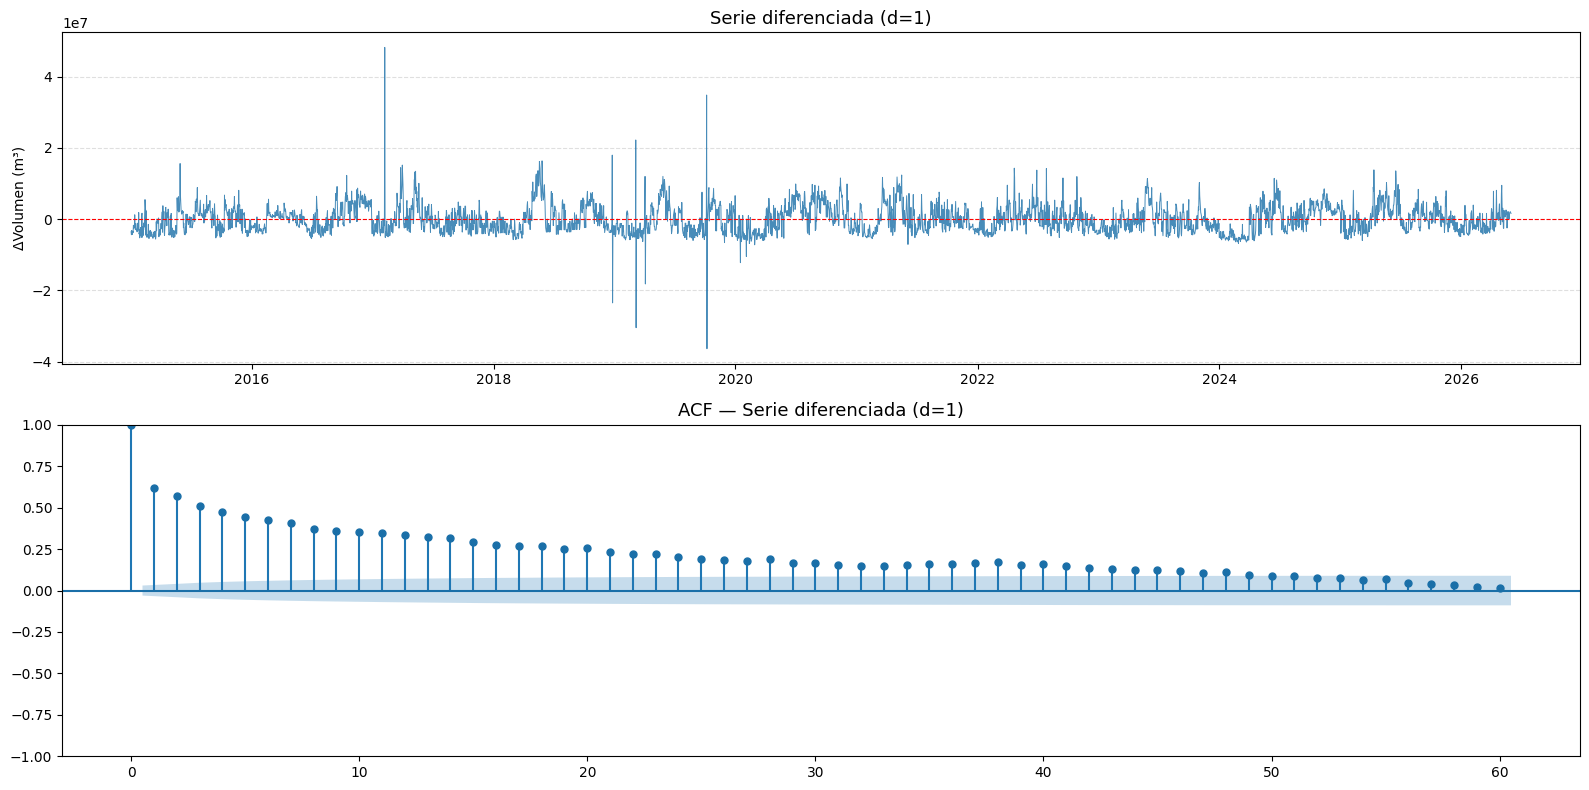

In [11]:
# ─── 10. DIFERENCIACIÓN Y RE-TEST ────────────────────────────────────────────
serie_diff1 = serie.diff().dropna()

resultado_diff = adfuller(serie_diff1, autolag="AIC")
print("=" * 50)
print("ADF SOBRE SERIE DIFERENCIADA (d=1)")
print("=" * 50)
print(f"Estadístico ADF : {resultado_diff[0]:.4f}")
print(f"p-valor         : {resultado_diff[1]:.6f}")
if resultado_diff[1] < 0.05:
    print("\n→ Con d=1 la serie ES estacionaria ✓")
else:
    print("\n→ Aún no es estacionaria, necesita d=2")

# ─── Visualizar serie diferenciada ───────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

axes[0].plot(serie_diff1, color="#1a6fa8", linewidth=0.7, alpha=0.8)
axes[0].axhline(0, color="red", linestyle="--", linewidth=0.8)
axes[0].set_title("Serie diferenciada (d=1)", fontsize=13)
axes[0].set_ylabel("ΔVolumen (m³)")
axes[0].grid(axis="y", linestyle="--", alpha=0.4)

plot_acf(serie_diff1, lags=60, ax=axes[1], color="#1a6fa8")
axes[1].set_title("ACF — Serie diferenciada (d=1)", fontsize=13)

plt.tight_layout()
plt.show()

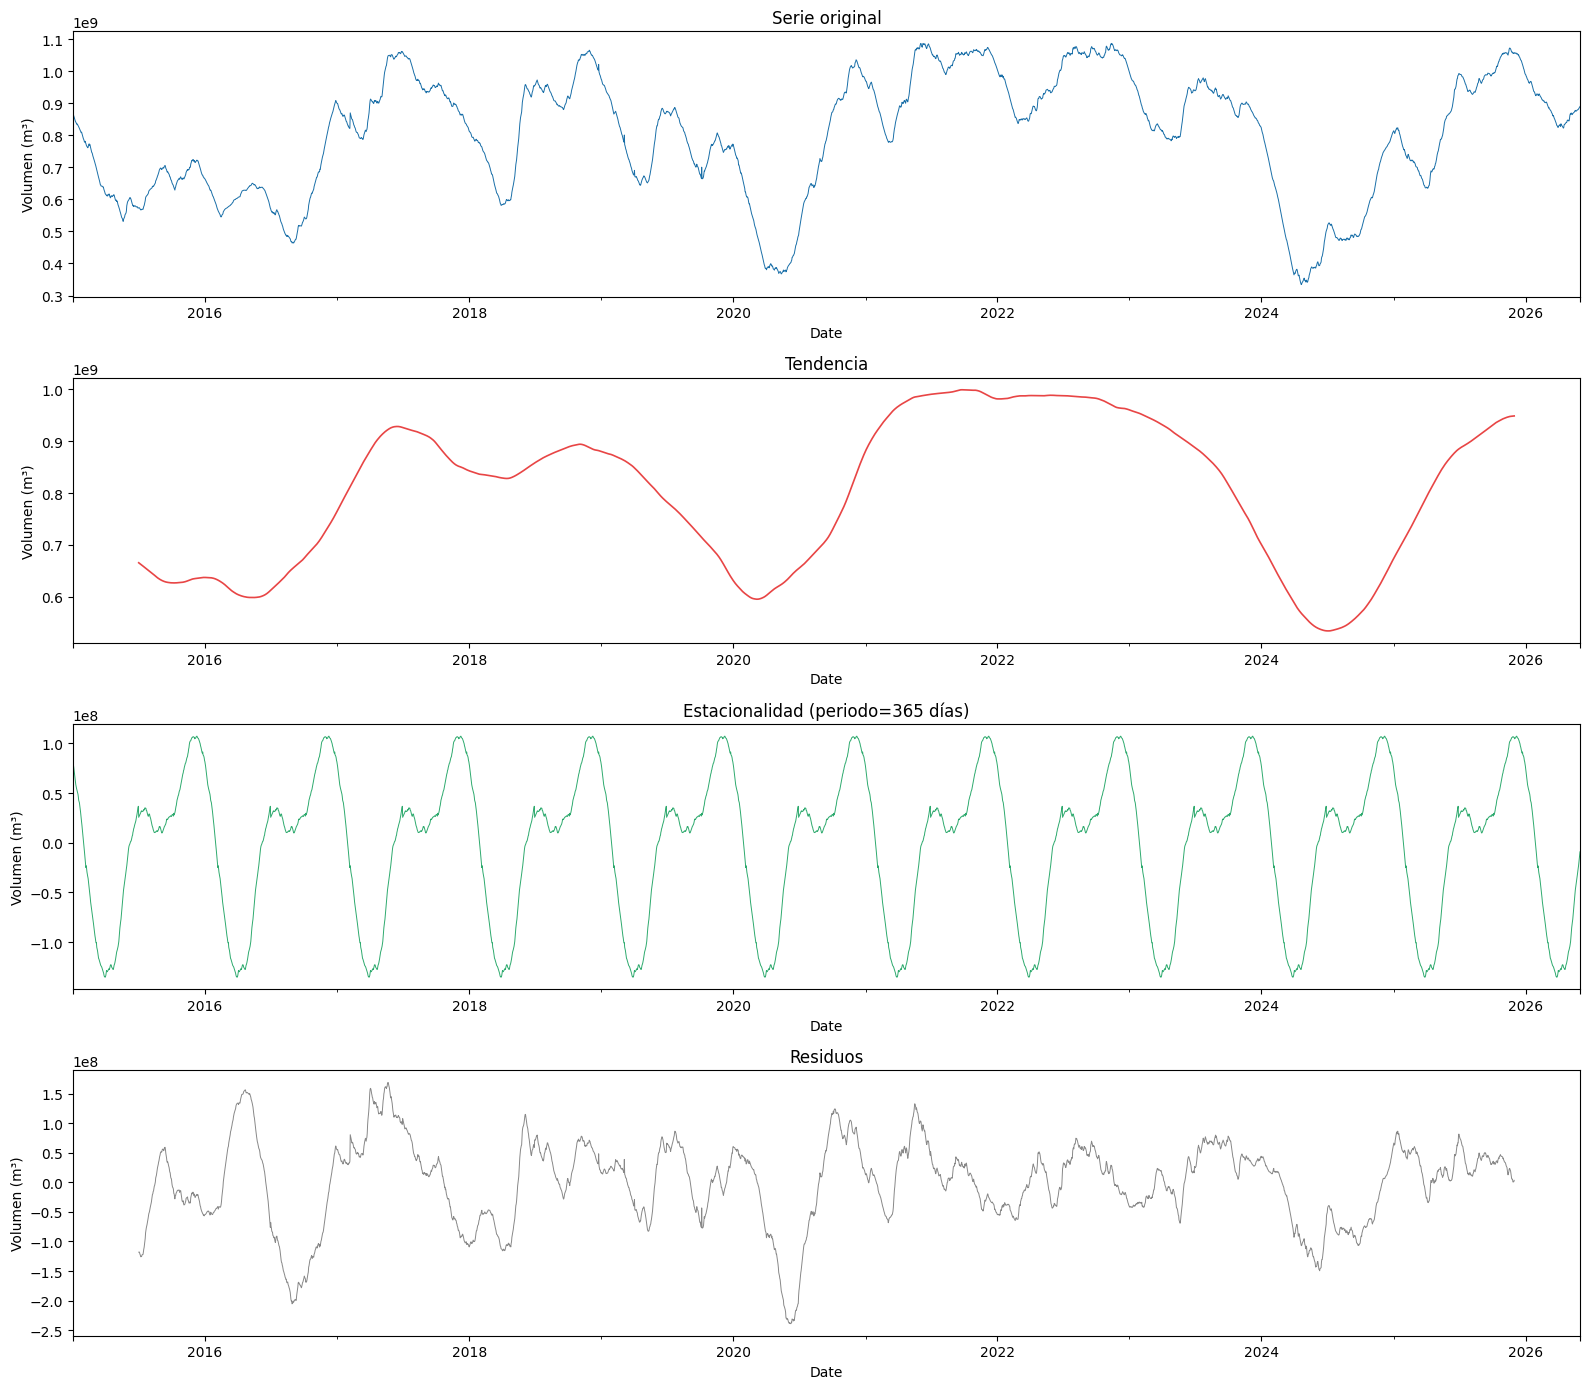

Outliers detectados en la serie diferenciada: 6

Fechas con cambios extremos:
Date
2017-02-06    48163000.0
2019-10-06    34803000.0
2019-03-06    22200000.0
2018-12-26   -23494000.0
2019-03-07   -30454000.0
2019-10-07   -36346000.0
Name: Value, dtype: float64


In [12]:
from statsmodels.tsa.seasonal import seasonal_decompose

# ─── 11. DESCOMPOSICIÓN ESTACIONAL ───────────────────────────────────────────
# Rellenar el día faltante antes de descomponer
serie_completa = serie.resample("D").interpolate(method="linear")

descomp = seasonal_decompose(serie_completa, model="additive", period=365)

fig, axes = plt.subplots(4, 1, figsize=(16, 14))
descomp.observed.plot(ax=axes[0], color="#1a6fa8", linewidth=0.7)
axes[0].set_title("Serie original", fontsize=12)
axes[0].set_ylabel("Volumen (m³)")

descomp.trend.plot(ax=axes[1], color="#e84545", linewidth=1.2)
axes[1].set_title("Tendencia", fontsize=12)
axes[1].set_ylabel("Volumen (m³)")

descomp.seasonal.plot(ax=axes[2], color="#2eaa6e", linewidth=0.7)
axes[2].set_title("Estacionalidad (periodo=365 días)", fontsize=12)
axes[2].set_ylabel("Volumen (m³)")

descomp.resid.plot(ax=axes[3], color="#888", linewidth=0.7)
axes[3].set_title("Residuos", fontsize=12)
axes[3].set_ylabel("Volumen (m³)")

plt.tight_layout()
plt.show()

# ─── 12. DETECCIÓN DE OUTLIERS (IQR) ─────────────────────────────────────────
serie_diff_clean = serie.diff().dropna()
Q1 = serie_diff_clean.quantile(0.25)
Q3 = serie_diff_clean.quantile(0.75)
IQR = Q3 - Q1
limite_inf = Q1 - 3 * IQR
limite_sup = Q3 + 3 * IQR

outliers = serie_diff_clean[(serie_diff_clean < limite_inf) | (serie_diff_clean > limite_sup)]
print(f"Outliers detectados en la serie diferenciada: {len(outliers)}")
print(f"\nFechas con cambios extremos:")
print(outliers.sort_values(ascending=False).head(10))

In [13]:
# ─── RESUMEN EDA ──────────────────────────────────────────────────────────────
print("=" * 55)
print("RESUMEN EDA — EMBALSE GUATAPÉ")
print("=" * 55)
print(f"""
DATOS
  Rango        : 2015-01-01 → 2026-05-31
  Registros    : 4168 días
  Nulos        : 0
  Días faltantes: 1 (2015-12-31)

ESTADÍSTICAS
  Volumen mín  : {serie.min()/1e9:.2f} Mm³
  Volumen máx  : {serie.max()/1e9:.2f} Mm³
  Volumen medio: {serie.mean()/1e9:.2f} Mm³

ESTACIONARIEDAD
  Serie original    : No estacionaria
  Serie con d=1     : Estacionaria ✓
  → Parámetro ARIMA : d = 1

ESTACIONALIDAD
  Periodo detectado : 365 días (anual)
  Meses críticos    : Mar-Abr (mínimos)
  Meses altos       : Nov-Dic (máximos)
  → Usar SARIMA con s = 365

OUTLIERS
  Años críticos     : 2015-2016, 2019-2020, 2024
  Causa probable    : El Niño / vertimientos extremos

DECISIONES PARA PROCESAMIENTO
  1. Imputar 2015-12-31 por interpolación lineal
  2. Conservar outliers (son eventos reales)
  3. Normalizar valores para LSTM (MinMaxScaler)
  4. Crear features: lag_7, lag_30, lag_365
     media_movil_7, media_movil_30
  5. Parámetro d=1 confirmado para ARIMA
""")

RESUMEN EDA — EMBALSE GUATAPÉ

DATOS
  Rango        : 2015-01-01 → 2026-05-31
  Registros    : 4168 días
  Nulos        : 0
  Días faltantes: 1 (2015-12-31)

ESTADÍSTICAS
  Volumen mín  : 0.33 Mm³
  Volumen máx  : 1.09 Mm³
  Volumen medio: 0.80 Mm³

ESTACIONARIEDAD
  Serie original    : No estacionaria
  Serie con d=1     : Estacionaria ✓
  → Parámetro ARIMA : d = 1

ESTACIONALIDAD
  Periodo detectado : 365 días (anual)
  Meses críticos    : Mar-Abr (mínimos)
  Meses altos       : Nov-Dic (máximos)
  → Usar SARIMA con s = 365

OUTLIERS
  Años críticos     : 2015-2016, 2019-2020, 2024
  Causa probable    : El Niño / vertimientos extremos

DECISIONES PARA PROCESAMIENTO
  1. Imputar 2015-12-31 por interpolación lineal
  2. Conservar outliers (son eventos reales)
  3. Normalizar valores para LSTM (MinMaxScaler)
  4. Crear features: lag_7, lag_30, lag_365
     media_movil_7, media_movil_30
  5. Parámetro d=1 confirmado para ARIMA

